# UN Calibration — Clean Reference Notebook

Self-contained Rizk-nominal reproduction of the capture_only UN model.
All physical constants live in **RIZK_CONSTANTS** (Section 1); free fit
parameters live in **MANUAL_PARAMS**. The dislocation density is **constant**
(Rizk 2025, Sec. 2.2.2: *"a constant dislocation density was used in this work"*).

**Sections**

1. Imports + RIZK_CONSTANTS + MANUAL_PARAMS + local model runner
2. Equations solved (capture_only family)
3. Smoke test at T = 1600 K, 1.3 % FIMA
4. Swelling vs T at 1.1 / 1.3 / 3.2 % FIMA (Rizk Fig. 3)
5. Dislocation density law $
ho_d(F, T)$ — diagnostics (optional law via `USE_RHO_FT`)
6. R_d, N_d vs T at 1.3 % FIMA (Rizk Fig. 7 / 8)
7. Gas partition vs T (Rizk Fig. 9 style)


## 1. Imports, constants, and model runner


In [1]:
import sys, pathlib
_HERE = pathlib.Path.cwd().resolve()
while _HERE.name != "un_calibration" and _HERE.parent != _HERE:
    _HERE = _HERE.parent
sys.path.insert(0, str(_HERE / "model"))

import un_data
import un_model as m

import math
import numpy as np
import matplotlib.pyplot as plt

print("Loaded:", m.__name__, "(capture_only physics)")


Loaded: un_model (capture_only physics)


In [2]:
# ============================================================================
# RIZK_CONSTANTS — every literature value used by the capture_only model.
# Source key: Rizk 2025 = J. Rizk et al., JNM 606 (2025) 155604.
# ============================================================================
RIZK_CONSTANTS = {
    # --- Geometry / matrix ---
    "GRAIN_RADIUS":        6.0e-6,    # m              (Rizk 2025, Table 2)
    "LATTICE_PARAMETER":   4.889e-10, # m, UN          (Rizk 2025, Table 2)
    "OMEGA_FG":            8.5e-29,   # m^3/at         (Rizk 2025, Table 2)
    "RADIUS_IN_LATTICE":   0.21e-9,   # m, ~a/(2sqrt(2)) (Rizk 2025)
    "GAMMA_B":             1.11,      # J/m^2          (Rizk 2025, Table 2)

    # --- Fission yield (Xe-equivalent stand-in for noble gases) ---
    "XE_YIELD":            0.24,      # at/fission     (Rizk 2025)

    # --- Dislocations (constant rho_d in this work, Rizk Sec. 2.2.2) ---
    "K_D":                 1.0e6,     # bub/m          (Rizk Eq. 11; UO2 ref [39])
    "R_D_LINE":            3.46e-10,  # m, ~a/sqrt(2)  (Rizk 2025, Table 2)
    "Z_D":                 5.0,       # geometric      (Rizk Eq. 22)

    # --- Xe diffusivity D_g = D1 + D3 (D2 negligible for Xe per Rizk) ---
    "D10_XE":              1.56e-3,   # m^2/s          (Rizk 2025, Table 2)
    "Q1_XE":               4.94,      # eV             (Rizk 2025, Table 2)
    "A30_XE":              1.85e-39,  # m^5            (Rizk 2025, Table 2; D3 = A30 * Fdot)
    # D2_xe diagnostics only -- not used in D_g.
    "A20_XE":              1.21e-67,
    "B21_XE":              25.87,
    "B22_XE":              -1.49,
    "B23_XE":              0.0,

    # --- Vacancy diffusivity (refit from Rizk Fig. 4) ---
    # NOTE: A20_VU here corrects an apparent Table 2 typo (paper reads 1.32e-19).
    "D10_VU":              1.35e-2,   # m^2/s
    "Q1_VU":               5.66,      # eV
    "A20_VU":              4.6304523933553033e-29,  # m^5  (refit from Fig. 4)
    "B21_VU":              -0.62,
    "B22_VU":              -0.04,

    # --- Re-solution shape b0(R) = pref * (a1 - a2 * exp(-b1/R))  (Rizk Eq. 8) ---
    "B0_PREFACTOR":        1.0e-25,   # m^6 at/bub/fission
    "B0_A1":               2.64,
    "B0_A2":               2.02,
    "B0_B1":               2.61e-9,   # m

    # --- Boltzmann ---
    "KB_EV":               8.617333262e-5,
    "KB_J":                1.380649e-23,
}

# ============================================================================
# RHO_FT_PARAMS -- optional T- and burnup-dependent dislocation-density law.
# Active only when MANUAL_PARAMS['USE_RHO_FT'] is True. Lineage:
#   - Saturating temperature shape: Blank 1984 Table 3 fit (specimen C3/1, 6.8 a/o)
#   - Ray-Blank burnup law:         Blank 1984 + v14 wrapper
# Not Rizk's own constants -- Rizk uses constant rho_d (Sec. 2.2.2).
# ============================================================================
RHO_FT_PARAMS = {
    # Saturating T-shape: f_sat(T) = rho_inf - (rho_inf - rho_at_anchor) * exp(-(T-T_anchor)/tau)
    # Units: 10^10 cm/cm^3 = 10^14 m^-2.  Normalised at T_REF when used as a multiplier.
    # T_ANCHOR sets WHERE the saturating curve takes the value RHO_AT_ANCHOR -- i.e. it
    # controls the temperature onset of the dislocation density rise.
    "RHO_INF":        9.104,    # asymptotic value (10^14 m^-2)
    "RHO_AT_ANCHOR":  6.357,    # value at T = T_ANCHOR (10^14 m^-2)
    "T_ANCHOR":       940.0,    # K, anchor temperature (lowers/raises the T-onset)
    "TAU":            203.76,   # K, characteristic width of the rise
    "T_REF":          1025.0,   # K, reference for normalisation

    # Ray-Blank burnup law: rho_0(F) = max(rho_FAB, C1 * (F - F0))
    "C1":        1.6e14,   # m^-2 / (a/o)
    "F0":        2.4,      # a/o threshold for linear growth
    "RHO_FAB":   3.0e13,   # m^-2, as-fabricated floor (Blank 1984)
}

# ============================================================================
# RHO_EXP_PARAMS -- Rizk NEAMS 2023 exponential dislocation-density law,
# Eq. (3.38) and Table 3.3 (calibrated for UN). Active only when
# MANUAL_PARAMS['USE_RHO_EXP'] is True.
#   rho_d(F, T) = rho_scale * RHO_0 * exp[ C * F / max(TD, T0 - T) ]
# bounded above by RHO_MAX (network saturation cap = 10^15 m^-2).
# Diverges as T -> T0 (1900 K), which is the breakaway-swelling onset.
# ============================================================================
RHO_EXP_PARAMS = {
    "RHO_0":   1.0e12,   # m^-2 (Rizk-NEAMS calibrated for UN; UC value: 2e13)
    "C":       49000.0,  # K * (FIMA)^-1
    "T0":      1900.0,   # K, divergence temperature (breakaway-swelling onset)
    "TD":      150.0,    # K, minimum gap T0-T to avoid asymptotic blow-up
    "RHO_MAX": 1.0e15,   # m^-2, network saturation cap
}

# ============================================================================
# MANUAL_PARAMS -- degrees of freedom (free fit + scaling factors).
# 1.0 on a scale = pure Rizk literature.
# ============================================================================
MANUAL_PARAMS = {
    "label": "manual_candidate",

    # --- Free fit parameters ---
    "f_n":          1.0e-6,   # nucleation factor (Olander 1e-7..1e-2; Rizk uses 1e-6)
    "rho_d":        3.0e13,   # m^-2  (Rizk Table 2; used when USE_RHO_FT=False)
    "fission_rate": 5.0e19,   # fiss/(m^3 s) (DN1/Rizk validation, LHR~100 kW/m, d=8.30 mm)

    # --- Dislocation-density law toggle (mutually exclusive) ---
    # All False             -> rho_d is the constant MANUAL_PARAMS['rho_d']
    #                          (Rizk 2025 paper choice, Sec. 2.2.2).
    # USE_RHO_FT = True     -> Blank-saturating + Ray-Blank burnup law
    #                          rho_d = rho_scale * rho_0(F) * f_sat_norm(T)
    #                          (parameters in RHO_FT_PARAMS).
    # USE_RHO_EXP = True    -> Rizk-NEAMS 2023 exponential law (Eq. 3.38)
    #                          rho_d = rho_scale * RHO_0 * exp[C*F/(T0-T)]
    #                          with RHO_MAX cap (parameters in RHO_EXP_PARAMS).
    #                          This is what Rizk's published NEAMS code uses.
    "USE_RHO_FT":    False,
    "USE_RHO_EXP":   False,
    "rho_scale":     1.0,     # multiplier consulted by both laws above

    # --- Scales (1.0 = Rizk-nominal) ---
    "coalescence_d_scale":  1.0,
    "capture_scale":        1.0,
    "gb_scale":             1.0,
    "gd_bubble_scale":      1.0,
    "gd_line_scale":        1.0,
    "gd_line_alpha":        1.0,
    "b_bulk_scale":         1.0,
    "b_dislocation_scale":  1.0,
    "Dv_scale":             1.0,
    "Dv_D1_scale":          1.0,
    "Dv_D2_scale":          1.0,
    "Dg_scale":             1.0,
    "Dg_D1_scale":          1.0,
    "Dg_D3_scale":          1.0,

    # Aggregate / deprecated scales (locked at 1.0)
    "b_scale":              1.0,
    "gd_scale":             1.0,
    "D2_xe_scale":          1.0,
}

# ============================================================================
# Build the Candidate (a frozen container for the free parameters + scales).
# ============================================================================
p_ = MANUAL_PARAMS
cand = m.Candidate(
    label=p_["label"], f_n=p_["f_n"],
    K_d=RIZK_CONSTANTS["K_D"], rho_d=p_["rho_d"],
    fission_rate=p_["fission_rate"],
    Dv_scale=p_["Dv_scale"], Dv_D1_scale=p_["Dv_D1_scale"], Dv_D2_scale=p_["Dv_D2_scale"],
    Dg_scale=p_["Dg_scale"], Dg_D1_scale=p_["Dg_D1_scale"], Dg_D3_scale=p_["Dg_D3_scale"],
    b_scale=p_["b_scale"], gb_scale=p_["gb_scale"], gd_scale=p_["gd_scale"],
    b_bulk_scale=p_["b_bulk_scale"], b_dislocation_scale=p_["b_dislocation_scale"],
    gd_bubble_scale=p_["gd_bubble_scale"], gd_line_scale=p_["gd_line_scale"],
    gd_line_alpha=p_["gd_line_alpha"],
    coalescence_d_scale=p_["coalescence_d_scale"], capture_scale=p_["capture_scale"],
    D2_xe_scale=p_["D2_xe_scale"],
)

print("Candidate:")
print(f"  label                = {cand.label}")
print(f"  f_n                  = {cand.f_n:.2e}")
print(f"  K_d                  = {cand.K_d:.2e}  (from RIZK_CONSTANTS)")
print(f"  fission_rate         = {cand.fission_rate:.2e}")
if MANUAL_PARAMS['USE_RHO_EXP']:
    print(f"  rho_d                = (T, F)-dependent via RHO_EXP_PARAMS  [Rizk-NEAMS exp law], rho_scale={MANUAL_PARAMS['rho_scale']:.3f}")
elif MANUAL_PARAMS['USE_RHO_FT']:
    print(f"  rho_d                = (T, F)-dependent via RHO_FT_PARAMS  [Blank-saturating], rho_scale={MANUAL_PARAMS['rho_scale']:.3f}")
else:
    print(f"  rho_d                = {cand.rho_d:.2e}  (constant, per Rizk 2025 Sec. 2.2.2)")
print(f"  scales (all 1.0 = Rizk-nominal):")
for s in ['gb_scale', 'gd_bubble_scale', 'gd_line_scale',
          'b_bulk_scale', 'b_dislocation_scale',
          'coalescence_d_scale', 'capture_scale']:
    print(f"    {s:21s} = {getattr(cand, s):.3f}")


Candidate:
  label                = manual_candidate
  f_n                  = 1.00e-06
  K_d                  = 1.00e+06  (from RIZK_CONSTANTS)
  fission_rate         = 5.00e+19
  rho_d                = 3.00e+13  (constant, per Rizk 2025 Sec. 2.2.2)
  scales (all 1.0 = Rizk-nominal):
    gb_scale              = 1.000
    gd_bubble_scale       = 1.000
    gd_line_scale         = 1.000
    b_bulk_scale          = 1.000
    b_dislocation_scale   = 1.000
    coalescence_d_scale   = 1.000
    capture_scale         = 1.000


In [3]:
# ============================================================================
# LOCAL MODEL RUNNER -- wires RIZK_CONSTANTS into the ODE solver explicitly.
# Every Rizk constant flows from RIZK_CONSTANTS (no silent module defaults).
# ============================================================================

# Patch m.b0_resolution so the resolution shape uses the b0 coefficients
# from RIZK_CONSTANTS. m.resolution_rates_UN calls m.b0_resolution(R).
def _b0_local(R):
    R = max(R, 1.0e-15)
    return RIZK_CONSTANTS["B0_PREFACTOR"] * (
        RIZK_CONSTANTS["B0_A1"]
        - RIZK_CONSTANTS["B0_A2"] * math.exp(-RIZK_CONSTANTS["B0_B1"] / R)
    )
m.b0_resolution = _b0_local

# Optional dislocation-density laws.
# (1) Blank-saturating + Ray-Blank: rho_d(T,F) = rho_scale * rho_0(F) * f_sat_norm(T)
def rho_d_FT(T, burnup, rho_scale=1.0, params=RHO_FT_PARAMS):
    f_sat   = params["RHO_INF"] - (params["RHO_INF"] - params["RHO_AT_ANCHOR"]) \
              * math.exp(-(T - params["T_ANCHOR"]) / params["TAU"])
    f_sat_0 = params["RHO_INF"] - (params["RHO_INF"] - params["RHO_AT_ANCHOR"]) \
              * math.exp(-(params["T_REF"] - params["T_ANCHOR"]) / params["TAU"])
    f_sat_norm = f_sat / f_sat_0
    rho_0 = max(params["RHO_FAB"], params["C1"] * (burnup - params["F0"]))
    return rho_scale * rho_0 * f_sat_norm

# (2) Rizk-NEAMS 2023 exponential law (Eq. 3.38, Table 3.3 calibrated for UN):
#     rho_d(T, F) = rho_scale * RHO_0 * exp[ C * F / max(TD, T0 - T) ],  capped at RHO_MAX.
# Note: 'burnup' is passed as % FIMA (a/o) to match the rest of the notebook;
# Rizk's c = 49000 K*(FIMA)^-1 uses FIMA as a fraction, so convert at boundary.
def rho_d_exp(T, burnup, rho_scale=1.0, params=RHO_EXP_PARAMS):
    F_frac = burnup / 100.0
    gap = max(params["TD"], params["T0"] - T)
    expo = min(params["C"] * F_frac / gap, 700.0)   # overflow-safe; cap kicks in anyway
    val = params["RHO_0"] * math.exp(expo)
    return rho_scale * min(val, params["RHO_MAX"])

def _build_un_params(T, bu, c, dt_h, n_modes):
    rk = RIZK_CONSTANTS
    if MANUAL_PARAMS['USE_RHO_FT'] and MANUAL_PARAMS['USE_RHO_EXP']:
        raise ValueError("USE_RHO_FT and USE_RHO_EXP are mutually exclusive; pick one.")
    if MANUAL_PARAMS['USE_RHO_EXP']:
        rho_d_actual = rho_d_exp(T, bu, MANUAL_PARAMS['rho_scale'])
    elif MANUAL_PARAMS['USE_RHO_FT']:
        rho_d_actual = rho_d_FT(T, bu, MANUAL_PARAMS['rho_scale'])
    else:
        rho_d_actual = c.rho_d
    return m.UNParameters(
        temperature=float(T),
        target_burnup_percent_fima=float(bu),
        dt=float(dt_h) * 3600.0,
        n_modes=int(n_modes),
        # Geometry / matrix
        grain_radius=rk["GRAIN_RADIUS"],
        lattice_parameter=rk["LATTICE_PARAMETER"],
        omega_fg=rk["OMEGA_FG"],
        radius_in_lattice=rk["RADIUS_IN_LATTICE"],
        gamma_b=rk["GAMMA_B"],
        xe_yield=rk["XE_YIELD"],
        # Dislocations
        r_d=rk["R_D_LINE"],
        Z_d=rk["Z_D"],
        K_d=rk["K_D"],
        # Xe diffusivity
        D10=rk["D10_XE"], Q1=rk["Q1_XE"],
        A20_xe=rk["A20_XE"], B21_xe=rk["B21_XE"],
        B22_xe=rk["B22_XE"], B23_xe=rk["B23_XE"],
        A30=rk["A30_XE"],
        # Vacancy diffusivity
        D10_vU=rk["D10_VU"], Q1_vU=rk["Q1_VU"],
        A20_vU_fig4_refit=rk["A20_VU"],
        B21_vU_refit=rk["B21_VU"], B22_vU_refit=rk["B22_VU"],
        # Boltzmann
        kB_eV=rk["KB_EV"], kB_J=rk["KB_J"],
        # Free-fit / candidate
        fission_rate=c.fission_rate,
        f_n=c.f_n,
        rho_d=rho_d_actual,
        # Scales
        Dv_scale=c.Dv_scale, Dg_scale=c.Dg_scale,
        Dg_D1_scale=c.Dg_D1_scale, Dg_D3_scale=c.Dg_D3_scale,
        Dv_D1_scale=c.Dv_D1_scale, Dv_D2_scale=c.Dv_D2_scale,
        D2_xe_scale=c.D2_xe_scale,
        b_scale=c.b_scale,
        b_bulk_scale=c.b_bulk_scale, b_dislocation_scale=c.b_dislocation_scale,
        gb_scale=c.gb_scale, gd_scale=c.gd_scale,
        gd_bubble_scale=c.gd_bubble_scale, gd_line_scale=c.gd_line_scale,
        gd_line_alpha=c.gd_line_alpha,
        coalescence_d_scale=c.coalescence_d_scale,
        capture_scale=c.capture_scale,
    )

def model_runner(T, bu, c, dt_h, n_modes, keep_history=False):
    p = _build_un_params(T, bu, c, dt_h, n_modes)
    hist, rates = m.solve_UN(p, keep_history=keep_history)
    pb_eq = hist["p_b_eq"][-1]; pd_eq = hist["p_d_eq"][-1]
    return {
        "T": float(T), "burnup": float(bu),
        "swelling_b_percent":  100.0 * hist["swelling_b"][-1],
        "swelling_d_percent":  100.0 * hist["swelling_d"][-1],
        "swelling_ig_percent": 100.0 * hist["swelling_ig"][-1],
        "Nb": hist["Nb"][-1], "Nd": hist["Nd"][-1],
        "Rb_nm": hist["Rb"][-1] * 1.0e9, "Rd_nm": hist["Rd"][-1] * 1.0e9,
        "p_b": hist["p_b"][-1], "p_b_eq": pb_eq,
        "p_d": hist["p_d"][-1], "p_d_eq": pd_eq,
        "p_b_over_eq": hist["p_b"][-1] / pb_eq if pb_eq > 0.0 else float('nan'),
        "p_d_over_eq": hist["p_d"][-1] / pd_eq if pd_eq > 0.0 else float('nan'),
        "matrix_gas_percent":      hist["matrix_gas_percent"][-1],
        "bulk_gas_percent":        hist["bulk_gas_percent"][-1],
        "dislocation_gas_percent": hist["dislocation_gas_percent"][-1],
        "qgb_gas_percent":         hist["qgb_gas_percent"][-1],
        "hist": hist if keep_history else None,
        "rates": rates,
    }


In [4]:
# Quick-look values (FAST settings, dt=12 h, n_modes=25).
DT_QUICK = 12.0
NM_QUICK = 25
out_1400  = model_runner(1400.0, 1.3, cand, DT_QUICK, NM_QUICK)
out_2000  = model_runner(2000.0, 1.3, cand, DT_QUICK, NM_QUICK)
out_q_1p1 = model_runner(2000.0, 1.1, cand, DT_QUICK, NM_QUICK)
out_q_3p2 = model_runner(2000.0, 3.2, cand, DT_QUICK, NM_QUICK)

print("=" * 60)
print("Quick-look values  (RIZK_CONSTANTS + MANUAL_PARAMS)")
print("=" * 60)
print(f"  Nd(1400 K, 1.3 % FIMA)   = {out_1400['Nd']:.3e} m^-3")
print(f"  Nd(2000 K, 1.3 % FIMA)   = {out_2000['Nd']:.3e} m^-3")
print(f"  Rd(2000 K, 1.3 % FIMA)   = {out_2000['Rd_nm']:.1f} nm")
print(f"  qgb (1.1 % FIMA, 2000 K) = {out_q_1p1['qgb_gas_percent']:.2f} %")
print(f"  qgb (3.2 % FIMA, 2000 K) = {out_q_3p2['qgb_gas_percent']:.2f} %")


Quick-look values  (RIZK_CONSTANTS + MANUAL_PARAMS)
  Nd(1400 K, 1.3 % FIMA)   = 2.902e+19 m^-3
  Nd(2000 K, 1.3 % FIMA)   = 8.464e+18 m^-3
  Rd(2000 K, 1.3 % FIMA)   = 186.3 nm
  qgb (1.1 % FIMA, 2000 K) = 6.15 %
  qgb (3.2 % FIMA, 2000 K) = 6.48 %


## 2. Equations solved (capture_only family)

The model evolves three intra-granular gas reservoirs (concentration of gas in
solution $c$, in bulk bubbles $m_b$, in dislocation bubbles $m_d$) and the
bubble populations $(N_b, V_b)$ and $(N_d, V_d)$. Equations active for
**capture_only** (φ-resolution **on**, nucleation-mass-coupling **on**,
bulk→dislocation capture **on**):

### Spectral 3-equation gas balance (sphere of radius $r_g$)

$$
\frac{\partial c}{\partial t} = D_g \nabla^2 c \;-\; (g_b + g_d)\, c \;+\; b_b\, m_b \;+\; b_d\, m_d \;+\; \beta
$$

$$
\frac{dm_b}{dt} = g_b\, c - b_b\, m_b, \qquad
\frac{dm_d}{dt} = g_d\, c - b_d\, m_d
$$

with $\beta = y_{\text{Xe}}\dot{F}$ (production rate). Solved spectrally on
$N_\text{modes}$ Fourier modes with backward Euler in time.

### Resolution rates (Nelson 1969 / Rizk Eq. 8)

$$
b_b = \dot{F}\, b_0(R_b + r_l), \qquad b_d = \dot{F}\, b_0(R_d + r_l), \qquad
b_0(R) = 10^{-25}\big[\,2.64 - 2.02\,e^{-2.61\!\times\!10^{-9}/R}\,\big]
$$

### Trapping rates (Rizk Eq. 22 / 23)

$$
g_b = 4\pi D_g (R_b + r_l) N_b
$$

$$
g_d = 4\pi D_g (R_d + r_l) N_d \;+\; \frac{2\pi D_g}{\ln(\Gamma_d / Z_d r_d) - 3/5}\,(\rho_d - 2 R_d N_d)
$$

(Rizk Eq. 23 has a published typo — extra $\rho_d$ on numerator gives wrong units; corrected here.)

### Bulk nucleation (Rizk Eq. 26)

$$
\nu_b = 8\pi f_n\, D_g\, \Omega_{fg}^{1/3}\, c^2, \qquad
\frac{dN_b}{dt} = \nu_b - b_b \phi_b N_b
$$

### Bulk → dislocation capture (Barani-like)

$$
f_\text{cap} = \min\!\Big(1,\ \max\big(0,\ s_\text{cap}\, N_d\, \Delta V_\text{cap}\big)\Big)
$$

### Coalescence (dislocation only — Rizk Eq. 11 / 15)

$$
N_d \leftarrow \frac{N_d}{1 + s_\text{coal,d}\, \cdot 4\,\lambda_d\, N_d\, \Delta V_{d,\text{growth}}},
\qquad
\lambda_d = \frac{2 - \xi}{2(1-\xi)^3}, \quad \xi = V_d N_d
$$

### Vacancy absorption (implicit, Rizk Eq. 21f)

$$
\frac{dn_v}{dt} = \frac{2\pi D_v\, \delta_{WS}\, N}{k_B T\, \zeta(R, N)}\,(p_\text{int} - p_\text{eq}),\qquad
p_\text{int} = \frac{k_B T\, m_\text{gas}}{n_v\, \Omega},\qquad
p_\text{eq} = \frac{2\gamma}{R} - \sigma_h
$$

### Volume / radius update

$$
V = \frac{\Omega_{fg}\, m_\text{gas} + \Omega\, n_v}{N},\qquad R = (3V/4\pi)^{1/3}
$$

### Initial dislocation-bubble population (Rizk Eq. 11)

$$
N_d(t=0) = K_d\, \rho_d, \qquad \rho_d = \text{const}\ (\text{Rizk Sec.~2.2.2})
$$


## 3. Smoke test at T = 1600 K, 1.3 % FIMA


In [5]:
DT_H = 12.0
N_MODES = 25

out = model_runner(1600.0, 1.3, cand, DT_H, N_MODES)

print(f"Single-point run at T = 1600 K, 1.3 % FIMA:\n")
print(f"  {'quantity':<26s} {'model':>12s}")
print(f"  {'swelling (dislocation)':<26s} {out['swelling_d_percent']:>11.3f} %")
print(f"  {'swelling (bulk)':<26s} {out['swelling_b_percent']:>11.3f} %")
print(f"  {'R_d':<26s} {out['Rd_nm']:>10.1f} nm")
print(f"  {'R_b':<26s} {out['Rb_nm']:>10.1f} nm")
print(f"  {'N_d':<26s} {out['Nd']:>12.2e}")
print(f"  {'N_b':<26s} {out['Nb']:>12.2e}")
print()
print(f"  Gas partition: matrix={out['matrix_gas_percent']:.1f}%  bulk={out['bulk_gas_percent']:.1f}%  "
      f"disl={out['dislocation_gas_percent']:.1f}%  q_gb={out['qgb_gas_percent']:.1f}%")


Single-point run at T = 1600 K, 1.3 % FIMA:

  quantity                          model
  swelling (dislocation)           2.877 %
  swelling (bulk)                  1.299 %
  R_d                              63.6 nm
  R_b                              13.7 nm
  N_d                            2.66e+19
  N_b                            1.20e+21

  Gas partition: matrix=0.1%  bulk=55.0%  disl=40.5%  q_gb=4.5%


## 4. Swelling vs T at 1.1 / 1.3 / 3.2 % FIMA

Three side-by-side panels, one per burnup. Model curves labelled
`dislocation/P2 swelling` and `bulk swelling`; experimental data
(Rizk Fig. 3) plotted as black markers. The 1.1 % FIMA panel splits
the experimental data by linear power (100 kW/m vs 119 kW/m); the
1.3 % and 3.2 % panels show the single available measurement series.


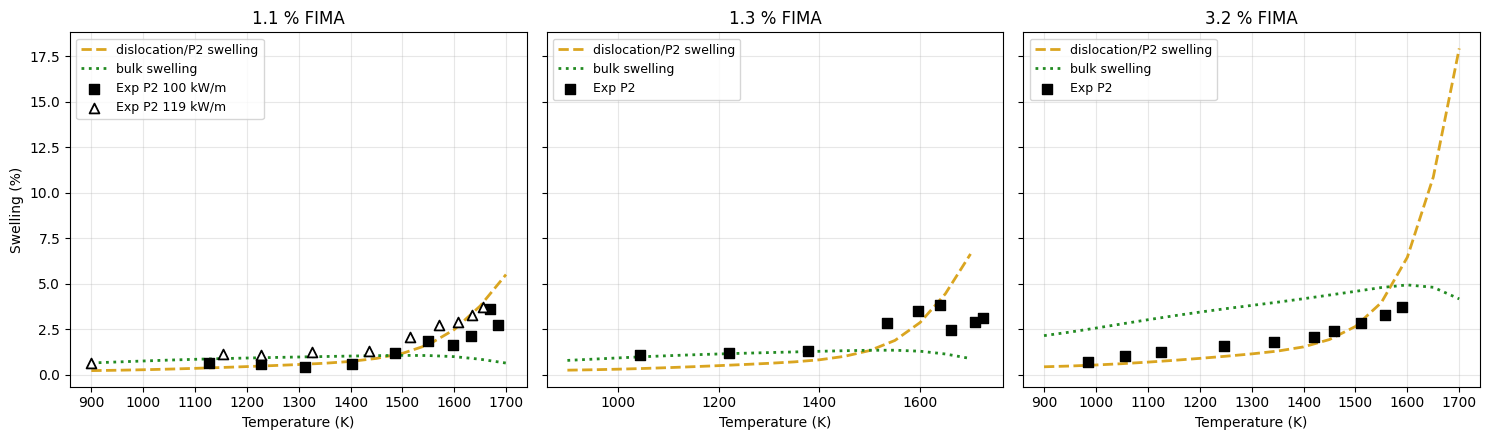

In [6]:
T_grid = np.arange(900, 1750, 50)
burnups = [1.1, 1.3, 3.2]
points = [(float(T), bu) for bu in burnups for T in T_grid]

results = [model_runner(T, bu, cand, DT_H, N_MODES) for (T, bu) in points]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, bu in zip(axes, burnups):
    rs = [r for r in results if abs(r['burnup'] - bu) < 0.01]
    Ts = [r['T'] for r in rs]
    swD = [r['swelling_d_percent'] for r in rs]
    swB = [r['swelling_b_percent'] for r in rs]
    ax.plot(Ts, swD, '--', linewidth=2, color='goldenrod', label='dislocation/P2 swelling')
    ax.plot(Ts, swB, ':',  linewidth=2, color='forestgreen', label='bulk swelling')

    if abs(bu - 1.1) < 0.01:
        exp_100 = [p for p in un_data.EXP_SWELLING_T if abs(p['burnup'] - 1.1) < 0.01 and p['series'] == '100 kW/m']
        exp_119 = [p for p in un_data.EXP_SWELLING_T if abs(p['burnup'] - 1.1) < 0.01 and p['series'] == '119 kW/m']
        ax.scatter([p['T'] for p in exp_100], [p['swelling'] for p in exp_100],
                   marker='s', s=50, color='black', label='Exp P2 100 kW/m', zorder=5)
        ax.scatter([p['T'] for p in exp_119], [p['swelling'] for p in exp_119],
                   marker='^', s=50, facecolor='white', edgecolor='black',
                   linewidth=1.3, label='Exp P2 119 kW/m', zorder=5)
    else:
        exp = [p for p in un_data.EXP_SWELLING_T if abs(p['burnup'] - bu) < 0.01]
        ax.scatter([p['T'] for p in exp], [p['swelling'] for p in exp],
                   marker='s', s=50, color='black', label='Exp P2', zorder=5)

    ax.set_xlabel('Temperature (K)')
    ax.set_title(f'{bu} % FIMA')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9, loc='upper left')
axes[0].set_ylabel('Swelling (%)')
plt.tight_layout()
plt.show()


## 5. Dislocation density law $\rho_d(F, T)$ — diagnostics

Two optional laws are available, controlled by toggles in `MANUAL_PARAMS`:

### Option A — `USE_RHO_FT = True`: Blank-saturating + Ray–Blank

$$\rho_d(F, T) = \rho_\text{scale} \cdot \rho_0(F) \cdot f_\text{sat,norm}(T)$$

- $\rho_0(F) = \max(\rho_\text{FAB},\; C_1 \cdot (F - F_0))$ — Ray–Blank burnup growth
- $f_\text{sat}(T) = \rho_\infty - (\rho_\infty - \rho_{T_a})\,\exp\!\left(-\dfrac{T - T_a}{\tau}\right)$, normalised at $T_\text{ref}$

`RHO_FT_PARAMS` defaults: $T_a = 940$ K (`T_ANCHOR`), $\rho_{T_a} = 6.357$ (`RHO_AT_ANCHOR`),
$\rho_\infty = 9.104$ (units of $10^{14}$ m⁻²), $\tau = 203.76$ K, $T_\text{ref} = 1025$ K,
$C_1 = 1.6\times 10^{14}$ m⁻²/(a/o), $F_0 = 2.4$ a/o, $\rho_\text{FAB} = 3\times 10^{13}$ m⁻².

### Option B — `USE_RHO_EXP = True`: Rizk-NEAMS 2023 exponential (Eq. 3.38)

$$\rho_d(F, T) = \rho_\text{scale} \cdot \rho_0 \cdot \exp\!\left[\frac{c\,F}{\max(T_d,\; T_0 - T)}\right], \qquad \rho_d \le \rho_\text{max}$$

This is **Rizk's published NEAMS BISON implementation**. It diverges as $T \to T_0$,
which is the breakaway-swelling onset, and is capped at $\rho_\text{max} = 10^{15}$ m⁻²
(network saturation).

`RHO_EXP_PARAMS` defaults (Rizk 2023, Table 3.3, calibrated for UN):
$\rho_0 = 10^{12}$ m⁻², $c = 49\,000$ K·(FIMA)⁻¹, $T_0 = 1900$ K, $T_d = 150$ K, $\rho_\text{max} = 10^{15}$ m⁻².

### Default

When both toggles are False, the simulation uses constant $\rho_d$ from `MANUAL_PARAMS['rho_d']`
(Rizk 2025 paper choice, Sec. 2.2.2). The plots below render both laws regardless of the toggle,
so you can compare them visually before flipping a switch.


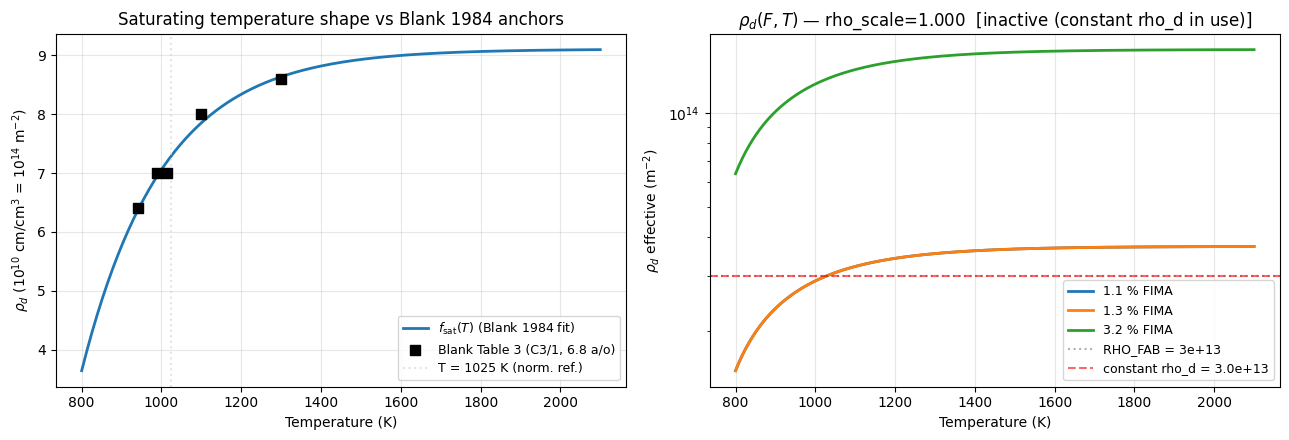

USE_RHO_FT = False
rho_d effective (m^-2):
   T (K)       1.1 %       1.3 %       3.2 %
     900    2.37e+13    2.37e+13    1.01e+14
    1300    3.55e+13    3.55e+13    1.52e+14
    1600    3.70e+13    3.70e+13    1.58e+14
    1800    3.73e+13    3.73e+13    1.59e+14
    2000    3.74e+13    3.74e+13    1.59e+14


In [7]:
T_grid = np.linspace(800, 2100, 300)

# (1) Saturating temperature shape (raw f_sat in 10^14 m^-2 units, i.e. 10^10 cm/cm^3)
fsat_raw = np.array([
    RHO_FT_PARAMS['RHO_INF']
    - (RHO_FT_PARAMS['RHO_INF'] - RHO_FT_PARAMS['RHO_AT_ANCHOR'])
    * math.exp(-(T - RHO_FT_PARAMS['T_ANCHOR']) / RHO_FT_PARAMS['TAU'])
    for T in T_grid
])

# Blank 1984 Table 3 anchors (specimen C3/1, 6.8 a/o burnup)
rb_T   = [940.0, 990.0, 1015.0, 1100.0, 1300.0]
rb_rho = [6.4,   7.0,   7.0,    8.0,    8.6]   # 10^10 cm/cm^3

# (2) Effective rho_d(F, T) at three burnups, using current rho_scale
rs = MANUAL_PARAMS['rho_scale']
burnups_plot = [1.1, 1.3, 3.2]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(T_grid, fsat_raw, '-', linewidth=2, color='tab:blue',
             label=r'$f_\mathrm{sat}(T)$ (Blank 1984 fit)')
axes[0].scatter(rb_T, rb_rho, marker='s', s=60, color='black',
                label='Blank Table 3 (C3/1, 6.8 a/o)', zorder=5)
axes[0].axvline(1025.0, color='lightgray', linestyle=':', alpha=0.6, label='T = 1025 K (norm. ref.)')
axes[0].set_xlabel('Temperature (K)')
axes[0].set_ylabel(r'$\rho_d$ ($10^{10}$ cm/cm$^3$ = $10^{14}$ m$^{-2}$)')
axes[0].set_title('Saturating temperature shape vs Blank 1984 anchors')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

for bu in burnups_plot:
    rho_eff = np.array([rho_d_FT(T, bu, rs) for T in T_grid])
    axes[1].plot(T_grid, rho_eff, linewidth=2, label=f'{bu} % FIMA')
axes[1].axhline(RHO_FT_PARAMS['RHO_FAB'], color='gray', linestyle=':', alpha=0.6,
                label=f"RHO_FAB = {RHO_FT_PARAMS['RHO_FAB']:.0e}")
axes[1].axhline(MANUAL_PARAMS['rho_d'], color='red', linestyle='--', alpha=0.6,
                label=f"constant rho_d = {MANUAL_PARAMS['rho_d']:.1e}")
axes[1].set_xlabel('Temperature (K)')
axes[1].set_ylabel(r'$\rho_d$ effective (m$^{-2}$)')
title_mode = 'ACTIVE' if MANUAL_PARAMS['USE_RHO_FT'] else 'inactive (constant rho_d in use)'
axes[1].set_title(f"$\\rho_d(F, T)$ — rho_scale={rs:.3f}  [{title_mode}]")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

print(f"USE_RHO_FT = {MANUAL_PARAMS['USE_RHO_FT']}")
print(f"rho_d effective (m^-2):")
print(f"  {'T (K)':>6s}  {'1.1 %':>10s}  {'1.3 %':>10s}  {'3.2 %':>10s}")
for T in [900, 1300, 1600, 1800, 2000]:
    cells = [rho_d_FT(T, bu, rs) for bu in burnups_plot]
    print(f"  {T:>6d}  {cells[0]:>10.2e}  {cells[1]:>10.2e}  {cells[2]:>10.2e}")


### 5b. 3D surface — $\rho_d(F, T)$ in SCIANTIX-native burnup units

The notebook works internally in **% FIMA** (a/o), but SCIANTIX commonly reports
burnup in **MWd/kgHM**. For U-based fuels at 200 MeV per fission:

$$1\,\%\,\text{FIMA} = 1\,\text{a/o} \approx 9.38\ \text{MWd/kgHM}$$

So Blank's reference specimen C3/1 at 6.8 a/o sits at **≈ 63.8 MWd/kgHM**.
The 3D surface below shows the rhoSat law over the full $(T, F)$ window;
red markers are the Blank Table 3 anchors, lifted onto the surface at $F=6.8$ a/o.


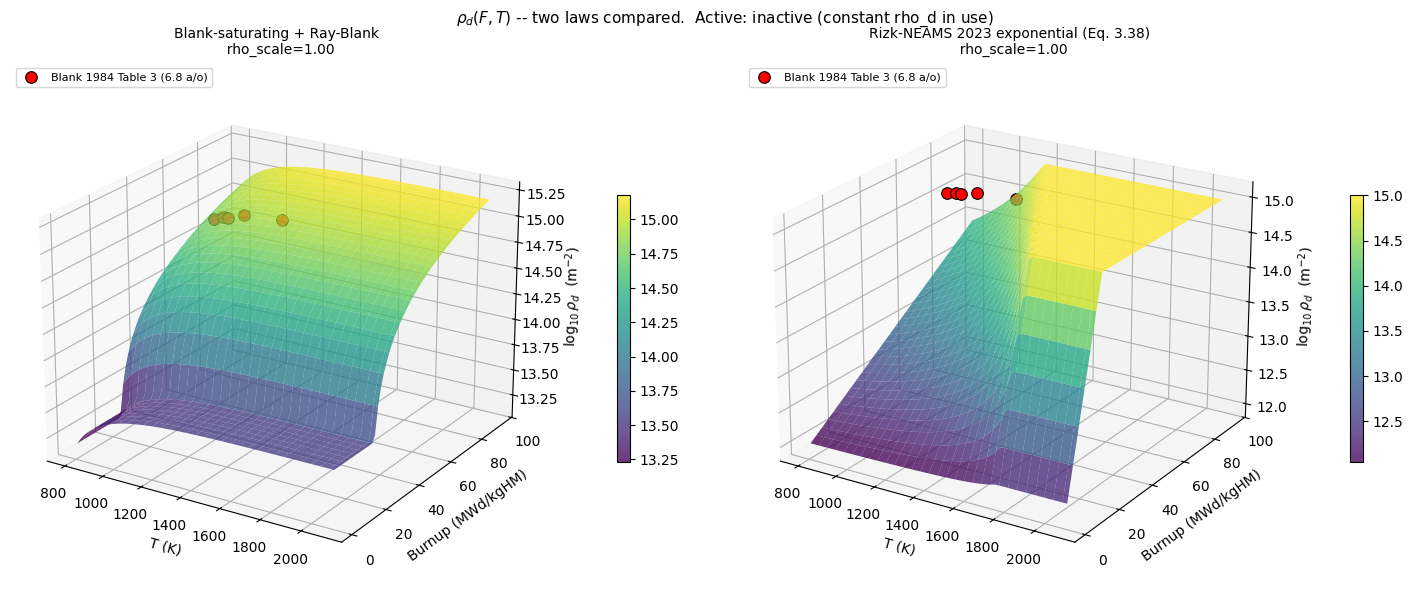

Conversion factor: 1 a/o = 9.38 MWd/kgHM  (200 MeV/fission, U heavy metal)
Blank C3/1 (6.8 a/o) = 63.8 MWd/kgHM
F0 threshold (rhoFT, 2.4 a/o) = 22.5 MWd/kgHM
T0 divergence (rho_exp) = 1900.0 K  (breakaway-swelling onset per Rizk-NEAMS 2023)

rho_d at Blank's anchor temperatures (F = 6.8 a/o, rho_scale = current):
   T (K)  Blank meas.    rhoFT law    rho_exp law
     940     6.40e+14     6.14e+14       3.22e+13
     990     7.00e+14     6.71e+14       3.89e+13
    1015     7.00e+14     6.95e+14       4.32e+13
    1100     8.00e+14     7.58e+14       6.44e+13
    1300     8.60e+14     8.33e+14       2.58e+14


In [8]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers the '3d' projection)

# ---- Burnup unit conversion ----
# 1 % FIMA (a/o) ≈ 9.38 MWd/kgHM for U-based fuels at 200 MeV/fission.
AO_TO_MWD_PER_KGHM = 9.38

# ---- Surface grid ----
T_vals = np.linspace(800.0, 2100.0, 60)
F_vals_ao = np.linspace(0.1, 10.0, 60)            # burnup in a/o (% FIMA)
T_mesh, F_mesh_ao = np.meshgrid(T_vals, F_vals_ao)
F_mesh_MWd = F_mesh_ao * AO_TO_MWD_PER_KGHM

rs = MANUAL_PARAMS['rho_scale']
RHO_FT_grid  = np.array([[rho_d_FT (T_mesh[i, j], F_mesh_ao[i, j], rs)
                          for j in range(T_mesh.shape[1])]
                         for i in range(T_mesh.shape[0])])
RHO_EXP_grid = np.array([[rho_d_exp(T_mesh[i, j], F_mesh_ao[i, j], rs)
                          for j in range(T_mesh.shape[1])]
                         for i in range(T_mesh.shape[0])])

# ---- Blank Table 3 anchors (specimen C3/1, F = 6.8 a/o) ----
blank_T      = [940.0, 990.0, 1015.0, 1100.0, 1300.0]
blank_rho_m2 = [6.4e14, 7.0e14, 7.0e14, 8.0e14, 8.6e14]   # converted from 10^10 cm/cm^3
blank_F_ao   = 6.8
blank_F_MWd  = blank_F_ao * AO_TO_MWD_PER_KGHM

def _active_law_label():
    if MANUAL_PARAMS['USE_RHO_EXP']:
        return 'Rizk-NEAMS exp [ACTIVE]'
    if MANUAL_PARAMS['USE_RHO_FT']:
        return 'Blank-saturating [ACTIVE]'
    return 'inactive (constant rho_d in use)'

fig = plt.figure(figsize=(15, 6))

for sp_idx, (grid, name, params_dict) in enumerate([
    (RHO_FT_grid,  'Blank-saturating + Ray-Blank',           RHO_FT_PARAMS),
    (RHO_EXP_grid, 'Rizk-NEAMS 2023 exponential (Eq. 3.38)', RHO_EXP_PARAMS),
]):
    ax = fig.add_subplot(1, 2, sp_idx + 1, projection='3d')
    log_grid = np.log10(grid)
    surf = ax.plot_surface(T_mesh, F_mesh_MWd, log_grid,
                           cmap='viridis', alpha=0.78, edgecolor='none',
                           rstride=2, cstride=2)

    ax.scatter(blank_T, [blank_F_MWd] * len(blank_T), np.log10(blank_rho_m2),
               color='red', s=70, edgecolor='black', linewidth=0.8, depthshade=False,
               label=f'Blank 1984 Table 3 (6.8 a/o)', zorder=10)

    ax.set_xlabel('T (K)')
    ax.set_ylabel('Burnup (MWd/kgHM)')
    ax.set_zlabel(r'$\log_{10} \rho_d$  (m$^{-2}$)')
    ax.set_title(f"{name}\n  rho_scale={rs:.2f}", fontsize=10)
    ax.view_init(elev=22, azim=-58)
    fig.colorbar(surf, ax=ax, shrink=0.5, pad=0.10)
    ax.legend(loc='upper left', fontsize=8)

fig.suptitle(f"$\\rho_d(F, T)$ -- two laws compared.  Active: {_active_law_label()}",
             fontsize=11, y=1.0)
plt.tight_layout()
plt.show()

# F0 reference for the rhoFT law
F0_MWd = RHO_FT_PARAMS['F0'] * AO_TO_MWD_PER_KGHM
T0_div = RHO_EXP_PARAMS['T0']  # Rizk-NEAMS divergence T

print(f"Conversion factor: 1 a/o = {AO_TO_MWD_PER_KGHM:.2f} MWd/kgHM  (200 MeV/fission, U heavy metal)")
print(f"Blank C3/1 (6.8 a/o) = {blank_F_MWd:.1f} MWd/kgHM")
print(f"F0 threshold (rhoFT, 2.4 a/o) = {F0_MWd:.1f} MWd/kgHM")
print(f"T0 divergence (rho_exp) = {T0_div} K  (breakaway-swelling onset per Rizk-NEAMS 2023)")

# Side-by-side numerical comparison at Blank's anchor temperatures
print()
print("rho_d at Blank's anchor temperatures (F = 6.8 a/o, rho_scale = current):")
print(f"  {'T (K)':>6}  {'Blank meas.':>11}  {'rhoFT law':>11}  {'rho_exp law':>13}")
for T_a in blank_T:
    blk = blank_rho_m2[blank_T.index(T_a)]
    a   = rho_d_FT(T_a, blank_F_ao, rs)
    b   = rho_d_exp(T_a, blank_F_ao, rs)
    print(f"  {T_a:>6.0f}  {blk:>11.2e}  {a:>11.2e}  {b:>13.2e}")


## 6. Dislocation-bubble radius and concentration vs T at 1.3 % FIMA

Compare against Rizk Fig. 7 (N_d) and Fig. 8 (R_d). The initial value
$N_d(t=0) = K_d \cdot \rho_d$; afterwards $N_d$ can only **decrease** via
coalescence as the dislocation bubbles grow. With `USE_RHO_FT=True` or
`USE_RHO_EXP=True`, the initial $N_d$ varies with $(T, F)$ via the
corresponding law in Section 5.


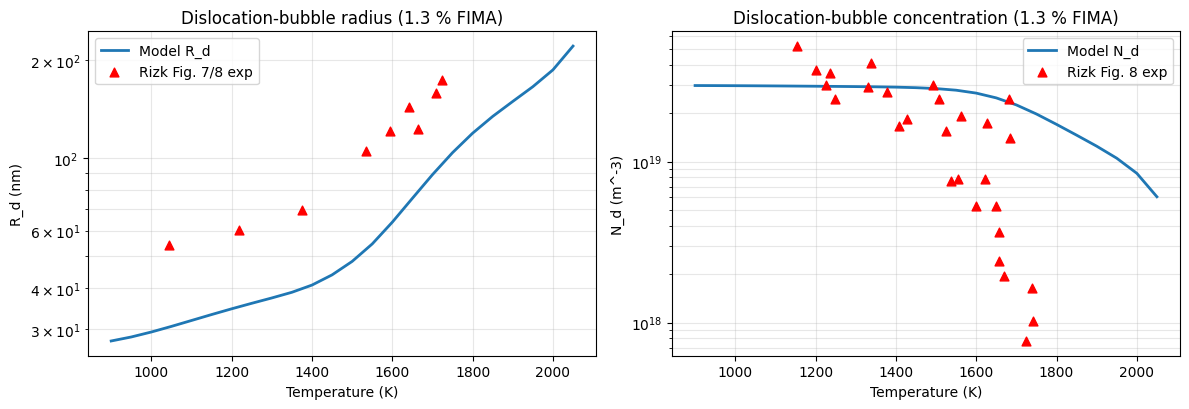

In [9]:
T_grid = np.arange(900, 2100, 50)
results = [model_runner(float(T), 1.3, cand, DT_H, N_MODES) for T in T_grid]
Ts = [r['T'] for r in results]
Rds = [r['Rd_nm'] for r in results]
Nds = [r['Nd'] for r in results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
ax1.plot(Ts, Rds, '-', linewidth=2, label='Model R_d')
ax1.scatter([p['T'] for p in un_data.EXP_RD_T_13], [p['R_nm'] for p in un_data.EXP_RD_T_13],
            color='red', s=40, marker='^', label='Rizk Fig. 7/8 exp', zorder=5)
ax1.set_xlabel('Temperature (K)')
ax1.set_ylabel('R_d (nm)')
ax1.set_yscale('log')
ax1.set_title('Dislocation-bubble radius (1.3 % FIMA)')
ax1.legend()
ax1.grid(alpha=0.3, which='both')

ax2.semilogy(Ts, Nds, '-', linewidth=2, label='Model N_d')
ax2.scatter([p['T'] for p in un_data.EXP_ND_T_13], [p['N'] for p in un_data.EXP_ND_T_13],
            color='red', s=40, marker='^', label='Rizk Fig. 8 exp', zorder=5)
ax2.set_xlabel('Temperature (K)')
ax2.set_ylabel('N_d (m^-3)')
ax2.set_title('Dislocation-bubble concentration (1.3 % FIMA)')
ax2.legend()
ax2.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()


## 7. Gas partition vs T at 1.3 % FIMA (Rizk Fig. 9 style)


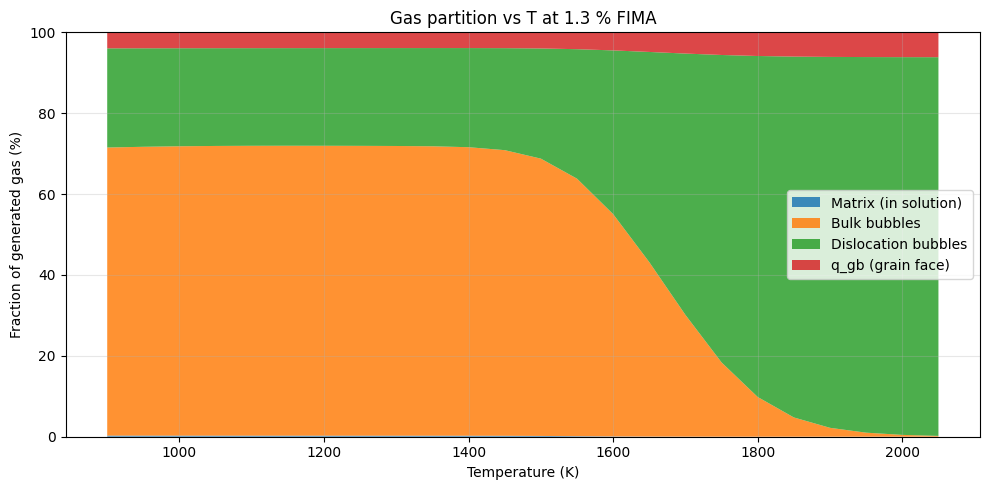

In [10]:
T_grid = np.arange(900, 2100, 50)
results = [model_runner(float(T), 1.3, cand, DT_H, N_MODES) for T in T_grid]
Ts = [r['T'] for r in results]
matrix = [r['matrix_gas_percent'] for r in results]
bulk = [r['bulk_gas_percent'] for r in results]
disl = [r['dislocation_gas_percent'] for r in results]
qgb = [r['qgb_gas_percent'] for r in results]

fig, ax = plt.subplots(figsize=(10, 5))
ax.stackplot(Ts, matrix, bulk, disl, qgb,
             labels=['Matrix (in solution)', 'Bulk bubbles',
                     'Dislocation bubbles', 'q_gb (grain face)'],
             alpha=0.85)
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Fraction of generated gas (%)')
ax.set_title('Gas partition vs T at 1.3 % FIMA')
ax.set_ylim(0, 100)
ax.legend(loc='center right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


---

End of clean notebook. To rerun cells: Kernel → Restart & Run All.
